In [1]:
import pandas as pd
import numpy as np

In [2]:
# Read CSV file into a DataFrame
df_metadata = pd.read_csv('SraRunTable.csv')

df_metadata["disease_status"] = (
    df_metadata["Sample Name"]
    .str.extract(r"(Patient|Control)", expand=False)
    .str.lower()
)

df_metadata["disease_status"] = df_metadata["disease_status"].map({
    "control": 0,
    "patient": 1
})

df_metadata["pair_id"] = (
    df_metadata["Sample Name"]
    .str.extract(r"(\d+)", expand=False)
    .astype(int)
)

df_metadata = df_metadata[["Run", "env_medium", "disease_status","pair_id"]]

df_metadata

,Run,env_medium,disease_status,pair_id
0,SRR32936395,Unstimulated saliva,1,17
1,SRR32936396,Unstimulated saliva,0,16
2,SRR32936397,Unstimulated saliva,1,3
3,SRR32936398,Unstimulated saliva,1,16
4,SRR32936408,Unstimulated saliva,1,2
...,...,...,...,...
247,SRR32938727,Supragingival swab,0,6
248,SRR32938728,Supragingival swab,1,6
249,SRR32938729,Supragingival swab,0,5
250,SRR32938733,Supragingival swab,1,4


In [3]:
df_asv = pd.read_csv('asv_table.tsv', sep = '\t', header=1)
df_asvt = df_asv.transpose()
new_header = df_asvt.iloc[0] 
df_asvt = df_asvt[1:] 
df_asvt.columns = new_header
df_asvt.reset_index(level=0, inplace=True, names=["Run"]) 
df_asvt.head()

#OTU ID,Run,afc7d633b31eacbcd06f9bd00fc92aba,d08c784d1836f43726d1162eadd9c4a4,58844abe1585eaed470c626af5e293c2,b9678f89d81e366818a5f4e9a4dbcbf6,2f2af02b1b3b9b47876e1c1f5c41d976,3307f2605d463abcc42024cdfef4c1fe,0f36313fefd8246ebc2d63bd1b70b6f4,37e7e601cfd657b615591af65747ff4d,e99ef6d33371880af23ceea3cfd58e56,...,ad98578086fac11d2c8d482bac525d19,a094de4e58b9f291cdea1600e53ae871,518528979dc71666ec2bba322b9e806b,dec2a6a67a2a8cb475b16c04cd60c712,30a3a61dfd94eef22b368c4e078bcdf2,19322f53614269ad24c1b6e83d85b1a8,8d451bdf92f1a3f59016162bd25ddb2b,234ba3e9c68c5efdb496a08c06eb4fd1,580a3724eadd91834f6b885e8132c4d3,e8035cd0cf8992d4de5c688f1923022a
0,SRR32936402,9477.0,9235.0,8983.0,8878.0,7642.0,7406.0,5917.0,4881.0,4300.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,SRR32936389,0.0,2047.0,0.0,0.0,945.0,9364.0,0.0,0.0,782.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,SRR32938709,0.0,234.0,0.0,811.0,7265.0,11794.0,4946.0,0.0,574.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,SRR32936396,12181.0,338.0,0.0,7772.0,19553.0,5817.0,11248.0,0.0,408.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,SRR32936412,17581.0,1706.0,0.0,6106.0,26832.0,6933.0,17034.0,0.0,2117.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


ASVs con prevalencia ≥ 20%: 552
ASVs totales: 8574
Porcentaje conservado: 6.44%


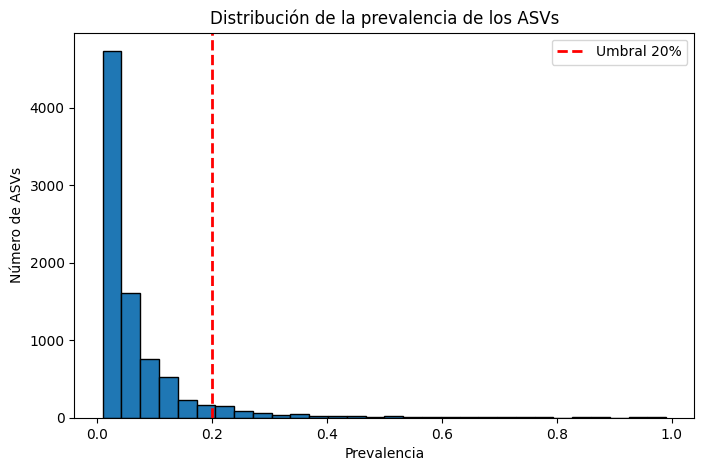

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Quedarse solo con las columnas de ASVs
asv_counts = df_asvt.drop(columns=["Run"])

# Prevalencia de cada ASV (fracción de muestras donde el conteo > 0)
prevalence = (asv_counts > 0).mean(axis=0)

# Número de ASVs que superan el 20%
n_asvs = (prevalence >= 0.2).sum()

print(f"ASVs con prevalencia ≥ 20%: {n_asvs}")
print(f"ASVs totales: {asv_counts.shape[1]}")
print(f"Porcentaje conservado: {100*n_asvs/asv_counts.shape[1]:.2f}%")

# Histograma de prevalencias
plt.figure(figsize=(8,5))
plt.hist(prevalence, bins=30, edgecolor="black")
plt.axvline(0.2, color="red", linestyle="--", linewidth=2,
            label="Umbral 20%")
plt.xlabel("Prevalencia")
plt.ylabel("Número de ASVs")
plt.title("Distribución de la prevalencia de los ASVs")
plt.legend()
plt.show()

In [5]:
# Seleccionar ASVs con prevalencia ≥ 20%
asv_counts_filtered = asv_counts.loc[:, prevalence >= 0.20]

# Comprobar resultados
print(f"ASVs después del filtrado: {asv_counts_filtered.shape[1]}")
print(f"ASVs eliminados: {asv_counts.shape[1] - asv_counts_filtered.shape[1]}")
print(f"Porcentaje conservado: {100*asv_counts_filtered.shape[1]/asv_counts.shape[1]:.2f}%")
:
df_asvt_filtered = pd.concat([df_asvt["Run"], asv_counts_filtered], axis=1)
df_asvt_filtered.head()

ASVs después del filtrado: 552
ASVs eliminados: 8022
Porcentaje conservado: 6.44%


,Run,afc7d633b31eacbcd06f9bd00fc92aba,d08c784d1836f43726d1162eadd9c4a4,b9678f89d81e366818a5f4e9a4dbcbf6,2f2af02b1b3b9b47876e1c1f5c41d976,3307f2605d463abcc42024cdfef4c1fe,0f36313fefd8246ebc2d63bd1b70b6f4,e99ef6d33371880af23ceea3cfd58e56,bccbf6a32db96f7b285bb310e4939979,2df318818bdb95fe9e968c46f24b6694,...,25a739f236938a52b28895558f2f4c65,626145cc8bcaf0764330664a8ca9266b,74925d8f20717e87ce604106d88cf028,3d2c71fbaf92c56b02e8a461e411901f,e5e617451fef60a6bf096cd5e879e5eb,af321296818b6f22280afe5ca810ec2e,37982d7213cf68b2468258261a050977,fe0d60c62bc7c9ce14dcb5cded7cddbd,9677c16ff1cbe3c88a8e53631965290d,c7aafba8d82d6edd5a180bb20191d623
0,SRR32936402,9477.0,9235.0,8878.0,7642.0,7406.0,5917.0,4300.0,3838.0,3437.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,SRR32936389,0.0,2047.0,0.0,945.0,9364.0,0.0,782.0,164.0,2054.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,SRR32938709,0.0,234.0,811.0,7265.0,11794.0,4946.0,574.0,1870.0,489.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,SRR32936396,12181.0,338.0,7772.0,19553.0,5817.0,11248.0,408.0,1771.0,876.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,SRR32936412,17581.0,1706.0,6106.0,26832.0,6933.0,17034.0,2117.0,2359.0,3806.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
#CLR transform

runs = df_asvt_filtered["Run"]

df_asvtclr = df_asvt_filtered.drop(columns="Run").astype(float)

df_asvtclr = df_asvtclr + 1

gm = np.exp(np.log(df_asvtclr).mean(axis=1))

df_asvtclr = np.log(df_asvtclr.div(gm, axis=0))

df_asvtclr.insert(0, "Run", runs)

df_asvtclr.head()

,Run,afc7d633b31eacbcd06f9bd00fc92aba,d08c784d1836f43726d1162eadd9c4a4,b9678f89d81e366818a5f4e9a4dbcbf6,2f2af02b1b3b9b47876e1c1f5c41d976,3307f2605d463abcc42024cdfef4c1fe,0f36313fefd8246ebc2d63bd1b70b6f4,e99ef6d33371880af23ceea3cfd58e56,bccbf6a32db96f7b285bb310e4939979,2df318818bdb95fe9e968c46f24b6694,...,25a739f236938a52b28895558f2f4c65,626145cc8bcaf0764330664a8ca9266b,74925d8f20717e87ce604106d88cf028,3d2c71fbaf92c56b02e8a461e411901f,e5e617451fef60a6bf096cd5e879e5eb,af321296818b6f22280afe5ca810ec2e,37982d7213cf68b2468258261a050977,fe0d60c62bc7c9ce14dcb5cded7cddbd,9677c16ff1cbe3c88a8e53631965290d,c7aafba8d82d6edd5a180bb20191d623
0,SRR32936402,7.826119,7.800255,7.760835,7.610936,7.579572,7.355145,7.035994,6.922358,6.812036,...,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609
1,SRR32936389,-1.544053,6.080566,-1.544053,5.308190,7.600682,-1.544053,5.119080,3.561893,6.083978,...,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053
2,SRR32938709,-1.323049,4.136536,5.376451,7.567912,8.052382,7.183487,5.031321,6.211179,4.871356,...,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049
3,SRR32936396,8.202806,4.621091,7.753502,8.676026,7.463803,8.123126,4.808806,6.274955,5.571598,...,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909
4,SRR32936412,8.166590,5.834452,7.109150,8.589347,7.236151,8.134985,6.050187,6.158376,6.636556,...,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041


In [7]:
#merge de ambas columnas
mg = pd.merge(df_asvtclr, df_metadata, on="Run", how="left")
mg

,Run,afc7d633b31eacbcd06f9bd00fc92aba,d08c784d1836f43726d1162eadd9c4a4,b9678f89d81e366818a5f4e9a4dbcbf6,2f2af02b1b3b9b47876e1c1f5c41d976,3307f2605d463abcc42024cdfef4c1fe,0f36313fefd8246ebc2d63bd1b70b6f4,e99ef6d33371880af23ceea3cfd58e56,bccbf6a32db96f7b285bb310e4939979,2df318818bdb95fe9e968c46f24b6694,...,3d2c71fbaf92c56b02e8a461e411901f,e5e617451fef60a6bf096cd5e879e5eb,af321296818b6f22280afe5ca810ec2e,37982d7213cf68b2468258261a050977,fe0d60c62bc7c9ce14dcb5cded7cddbd,9677c16ff1cbe3c88a8e53631965290d,c7aafba8d82d6edd5a180bb20191d623,env_medium,disease_status,pair_id
0,SRR32936402,7.826119,7.800255,7.760835,7.610936,7.579572,7.355145,7.035994,6.922358,6.812036,...,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,Unstimulated saliva,1,14
1,SRR32936389,-1.544053,6.080566,-1.544053,5.308190,7.600682,-1.544053,5.119080,3.561893,6.083978,...,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,Unstimulated saliva,1,20
2,SRR32938709,-1.323049,4.136536,5.376451,7.567912,8.052382,7.183487,5.031321,6.211179,4.871356,...,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,Supragingival swab,1,15
3,SRR32936396,8.202806,4.621091,7.753502,8.676026,7.463803,8.123126,4.808806,6.274955,5.571598,...,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,Unstimulated saliva,0,16
4,SRR32936412,8.166590,5.834452,7.109150,8.589347,7.236151,8.134985,6.050187,6.158376,6.636556,...,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,Unstimulated saliva,0,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,SRR32936397,7.272687,5.253448,5.435925,7.422768,7.782894,7.685705,5.271899,5.726705,6.115402,...,3.134115,-1.725697,-1.725697,2.550969,2.631012,-0.339403,-1.725697,Unstimulated saliva,1,3
97,SRR32938719,-1.496125,5.683182,3.831751,7.928762,8.945170,6.510909,5.167007,6.275785,5.445065,...,-1.496125,1.969610,-1.496125,-1.496125,-1.496125,-1.496125,-1.496125,Supragingival swab,0,10
98,SRR32936399,5.863502,6.220812,-1.497873,7.932084,7.217351,7.530225,1.637621,5.964916,6.168348,...,2.191006,-0.399261,-1.497873,1.497859,-1.497873,-1.497873,3.361939,Unstimulated saliva,0,15
99,SRR32938700,-1.413184,0.784041,-1.413184,5.850846,9.801228,5.005181,3.924354,3.722615,5.275171,...,1.764870,-1.413184,-1.413184,1.631339,-1.413184,2.324486,-1.413184,Supragingival swab,1,19


In [8]:
#ohe
df_analisis_ohe = pd.get_dummies(mg, columns= ['env_medium'], drop_first=False)
df_analisis_ohe.head()

,Run,afc7d633b31eacbcd06f9bd00fc92aba,d08c784d1836f43726d1162eadd9c4a4,b9678f89d81e366818a5f4e9a4dbcbf6,2f2af02b1b3b9b47876e1c1f5c41d976,3307f2605d463abcc42024cdfef4c1fe,0f36313fefd8246ebc2d63bd1b70b6f4,e99ef6d33371880af23ceea3cfd58e56,bccbf6a32db96f7b285bb310e4939979,2df318818bdb95fe9e968c46f24b6694,...,e5e617451fef60a6bf096cd5e879e5eb,af321296818b6f22280afe5ca810ec2e,37982d7213cf68b2468258261a050977,fe0d60c62bc7c9ce14dcb5cded7cddbd,9677c16ff1cbe3c88a8e53631965290d,c7aafba8d82d6edd5a180bb20191d623,disease_status,pair_id,env_medium_Supragingival swab,env_medium_Unstimulated saliva
0,SRR32936402,7.826119,7.800255,7.760835,7.610936,7.579572,7.355145,7.035994,6.922358,6.812036,...,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,1,14,False,True
1,SRR32936389,-1.544053,6.080566,-1.544053,5.308190,7.600682,-1.544053,5.119080,3.561893,6.083978,...,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,1,20,False,True
2,SRR32938709,-1.323049,4.136536,5.376451,7.567912,8.052382,7.183487,5.031321,6.211179,4.871356,...,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,1,15,True,False
3,SRR32936396,8.202806,4.621091,7.753502,8.676026,7.463803,8.123126,4.808806,6.274955,5.571598,...,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,0,16,False,True
4,SRR32936412,8.166590,5.834452,7.109150,8.589347,7.236151,8.134985,6.050187,6.158376,6.636556,...,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,0,9,False,True


In [9]:
meta_cols = [
    "Run",
    "disease_status",
    "pair_id",
    "env_medium_Supragingival swab",
    "env_medium_Unstimulated saliva"
]

X = df_analisis_ohe.drop(columns=meta_cols)
X.head()

,afc7d633b31eacbcd06f9bd00fc92aba,d08c784d1836f43726d1162eadd9c4a4,b9678f89d81e366818a5f4e9a4dbcbf6,2f2af02b1b3b9b47876e1c1f5c41d976,3307f2605d463abcc42024cdfef4c1fe,0f36313fefd8246ebc2d63bd1b70b6f4,e99ef6d33371880af23ceea3cfd58e56,bccbf6a32db96f7b285bb310e4939979,2df318818bdb95fe9e968c46f24b6694,23e4c18880db9ea26fff40c84949538a,...,25a739f236938a52b28895558f2f4c65,626145cc8bcaf0764330664a8ca9266b,74925d8f20717e87ce604106d88cf028,3d2c71fbaf92c56b02e8a461e411901f,e5e617451fef60a6bf096cd5e879e5eb,af321296818b6f22280afe5ca810ec2e,37982d7213cf68b2468258261a050977,fe0d60c62bc7c9ce14dcb5cded7cddbd,9677c16ff1cbe3c88a8e53631965290d,c7aafba8d82d6edd5a180bb20191d623
0,7.826119,7.800255,7.760835,7.610936,7.579572,7.355145,7.035994,6.922358,6.812036,6.784613,...,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609
1,-1.544053,6.080566,-1.544053,5.308190,7.600682,-1.544053,5.119080,3.561893,6.083978,-1.544053,...,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053
2,-1.323049,4.136536,5.376451,7.567912,8.052382,7.183487,5.031321,6.211179,4.871356,-1.323049,...,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049
3,8.202806,4.621091,7.753502,8.676026,7.463803,8.123126,4.808806,6.274955,5.571598,-1.204909,...,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909
4,8.166590,5.834452,7.109150,8.589347,7.236151,8.134985,6.050187,6.158376,6.636556,-1.608041,...,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041


In [10]:
meta_cols2 = [
    "disease_status",
    "pair_id",
    "env_medium_Supragingival swab",
    "env_medium_Unstimulated saliva"
]
# 1. Fijar la columna de muestras como índice y LUEGO trasponer
X2 = (
    df_analisis_ohe
    .set_index("Run")  
    .drop(columns=meta_cols2, errors="ignore")
    .T
)

In [11]:
X2.head()

Run,SRR32936402,SRR32936389,SRR32938709,SRR32936396,SRR32936412,SRR32938731,SRR32938711,SRR32938723,SRR32938694,SRR32938705,...,SRR32936387,SRR32938727,SRR32936398,SRR32936425,SRR32936411,SRR32936397,SRR32938719,SRR32936399,SRR32938700,SRR32936400
afc7d633b31eacbcd06f9bd00fc92aba,7.826119,-1.544053,-1.323049,8.202806,8.166590,-1.368005,-1.013931,-1.161852,-1.465493,-1.616949,...,7.485905,5.573805,8.671835,5.912910,-1.506609,7.272687,-1.496125,5.863502,-1.413184,6.930358
d08c784d1836f43726d1162eadd9c4a4,7.800255,6.080566,4.136536,4.621091,5.834452,-1.368005,4.067473,-1.161852,-1.465493,3.739637,...,3.453823,6.170724,3.537822,6.051437,5.899494,5.253448,5.683182,6.220812,0.784041,3.380689
b9678f89d81e366818a5f4e9a4dbcbf6,7.760835,-1.544053,5.376451,7.753502,7.109150,3.749989,-1.013931,-1.161852,5.157243,-1.616949,...,7.585150,5.036119,7.336070,7.914567,3.175522,5.435925,3.831751,-1.497873,-1.413184,6.035706
2f2af02b1b3b9b47876e1c1f5c41d976,7.610936,5.308190,7.567912,8.676026,8.589347,7.303110,8.888155,6.965553,7.284873,5.999826,...,8.524153,6.565470,8.278039,9.445464,5.364482,7.422768,7.928762,7.932084,5.850846,9.194470
3307f2605d463abcc42024cdfef4c1fe,7.579572,7.600682,8.052382,7.463803,7.236151,8.089117,9.876790,4.942941,8.948180,7.833982,...,8.321874,9.994817,3.851795,6.935901,7.033323,7.782894,8.945170,7.217351,9.801228,6.849517


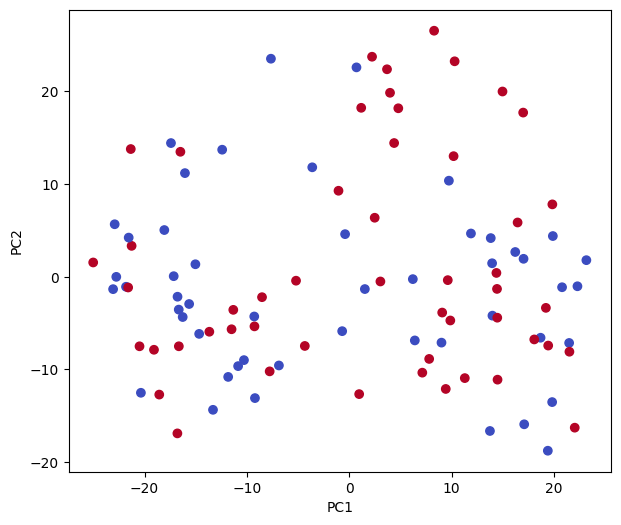

In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(7,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df_analisis_ohe["disease_status"],
    cmap="coolwarm"
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

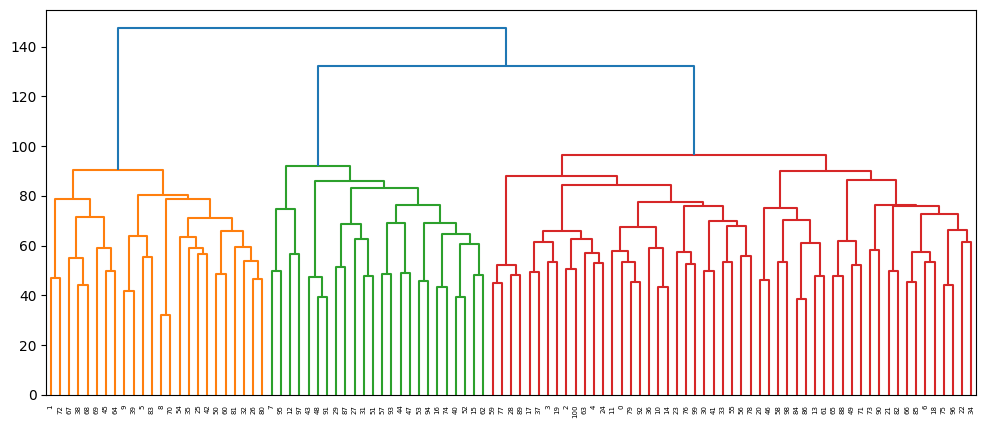

In [13]:
from scipy.cluster.hierarchy import linkage, dendrogram

Z = linkage(X, method="ward")

plt.figure(figsize=(12,5))
dendrogram(Z)
plt.show()

C:\users\Usuario\venv\lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
C:\users\Usuario\venv\lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


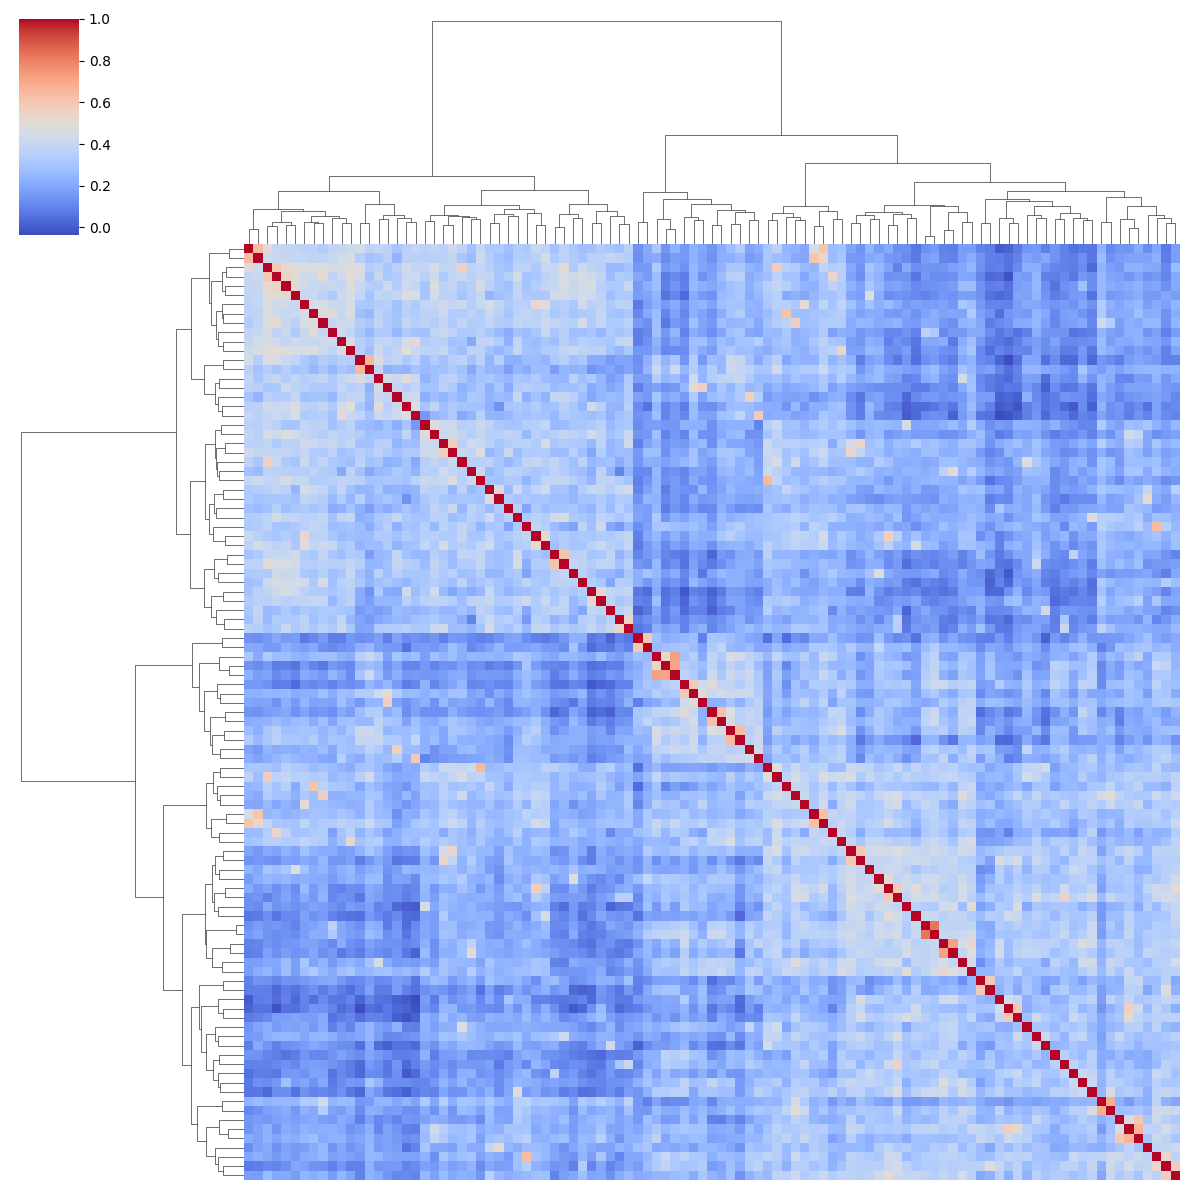

In [36]:
import seaborn as sns
corr_X = X.T.corr(method="pearson")

sns.clustermap(
    corr_X,
    method="ward",        
    metric="euclidean",   
    cmap="coolwarm",      
    figsize=(12, 12),
    xticklabels=False,    
    yticklabels=False
)

In [16]:
X2

Run,SRR32936402,SRR32936389,SRR32938709,SRR32936396,SRR32936412,SRR32938731,SRR32938711,SRR32938723,SRR32938694,SRR32938705,...,SRR32936387,SRR32938727,SRR32936398,SRR32936425,SRR32936411,SRR32936397,SRR32938719,SRR32936399,SRR32938700,SRR32936400
afc7d633b31eacbcd06f9bd00fc92aba,7.826119,-1.544053,-1.323049,8.202806,8.166590,-1.368005,-1.013931,-1.161852,-1.465493,-1.616949,...,7.485905,5.573805,8.671835,5.912910,-1.506609,7.272687,-1.496125,5.863502,-1.413184,6.930358
d08c784d1836f43726d1162eadd9c4a4,7.800255,6.080566,4.136536,4.621091,5.834452,-1.368005,4.067473,-1.161852,-1.465493,3.739637,...,3.453823,6.170724,3.537822,6.051437,5.899494,5.253448,5.683182,6.220812,0.784041,3.380689
b9678f89d81e366818a5f4e9a4dbcbf6,7.760835,-1.544053,5.376451,7.753502,7.109150,3.749989,-1.013931,-1.161852,5.157243,-1.616949,...,7.585150,5.036119,7.336070,7.914567,3.175522,5.435925,3.831751,-1.497873,-1.413184,6.035706
2f2af02b1b3b9b47876e1c1f5c41d976,7.610936,5.308190,7.567912,8.676026,8.589347,7.303110,8.888155,6.965553,7.284873,5.999826,...,8.524153,6.565470,8.278039,9.445464,5.364482,7.422768,7.928762,7.932084,5.850846,9.194470
3307f2605d463abcc42024cdfef4c1fe,7.579572,7.600682,8.052382,7.463803,7.236151,8.089117,9.876790,4.942941,8.948180,7.833982,...,8.321874,9.994817,3.851795,6.935901,7.033323,7.782894,8.945170,7.217351,9.801228,6.849517
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
af321296818b6f22280afe5ca810ec2e,-1.330609,-1.544053,-1.323049,-1.204909,-1.608041,-1.368005,-1.013931,-1.161852,-1.465493,-1.616949,...,-1.325300,0.700136,-1.266199,4.237233,4.110162,-1.725697,-1.496125,-1.497873,-1.413184,-1.328841
37982d7213cf68b2468258261a050977,-1.330609,-1.544053,-1.323049,-1.204909,-1.608041,-1.368005,-1.013931,-1.161852,-1.465493,-1.616949,...,-1.325300,-0.909302,-1.266199,2.847040,-1.506609,2.550969,-1.496125,1.497859,1.631339,-1.328841
fe0d60c62bc7c9ce14dcb5cded7cddbd,-1.330609,-1.544053,-1.323049,-1.204909,-1.608041,-1.368005,-1.013931,-1.161852,-1.465493,-1.616949,...,0.284137,0.189310,1.131696,-1.311843,-1.506609,2.631012,-1.496125,-1.497873,-1.413184,-1.328841
9677c16ff1cbe3c88a8e53631965290d,-1.330609,-1.544053,-1.323049,-1.204909,-1.608041,-1.368005,-1.013931,-1.161852,-1.465493,-1.616949,...,-1.325300,0.189310,-1.266199,-1.311843,-1.506609,-0.339403,-1.496125,-1.497873,2.324486,1.504372


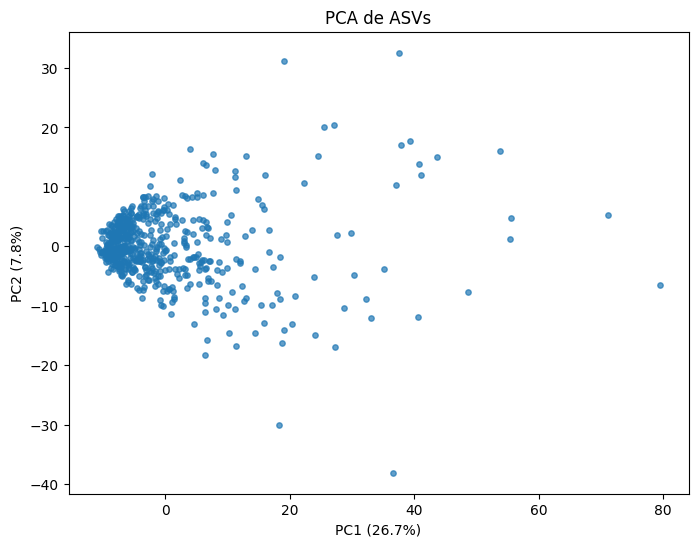

In [42]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X2)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    s=15,
    alpha=0.7
)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA de ASVs")

plt.show()

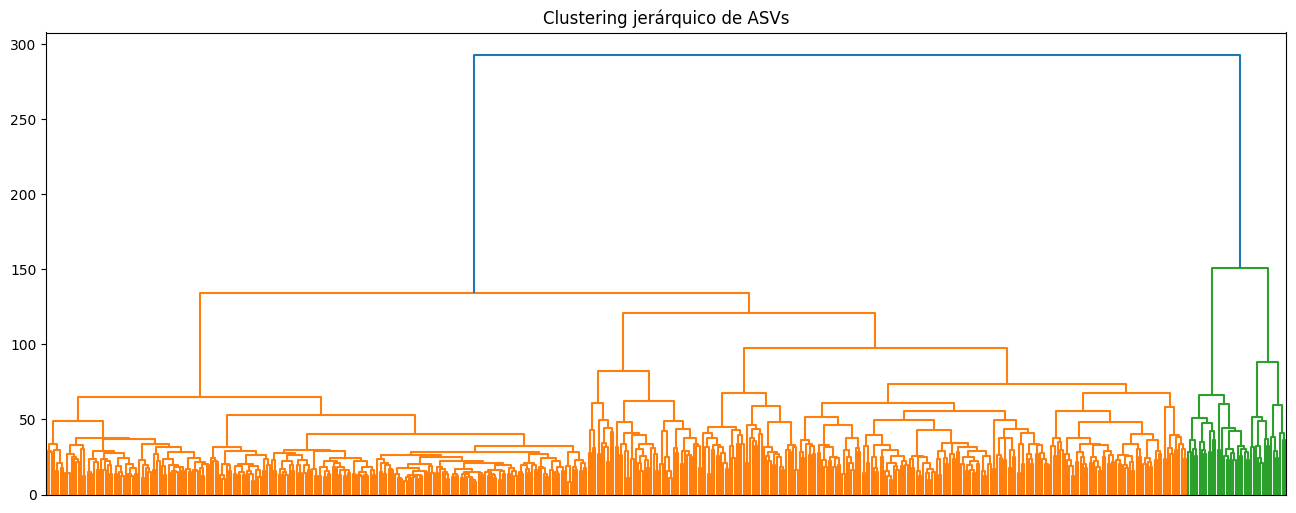

In [18]:
from scipy.cluster.hierarchy import linkage, dendrogram

Z = linkage(
    X2,
    method="ward",
    metric="euclidean"
)

plt.figure(figsize=(16,6))

dendrogram(
    Z,
    no_labels=True
)

plt.title("Clustering jerárquico de ASVs")

plt.show()

C:\users\Usuario\venv\lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
C:\users\Usuario\venv\lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


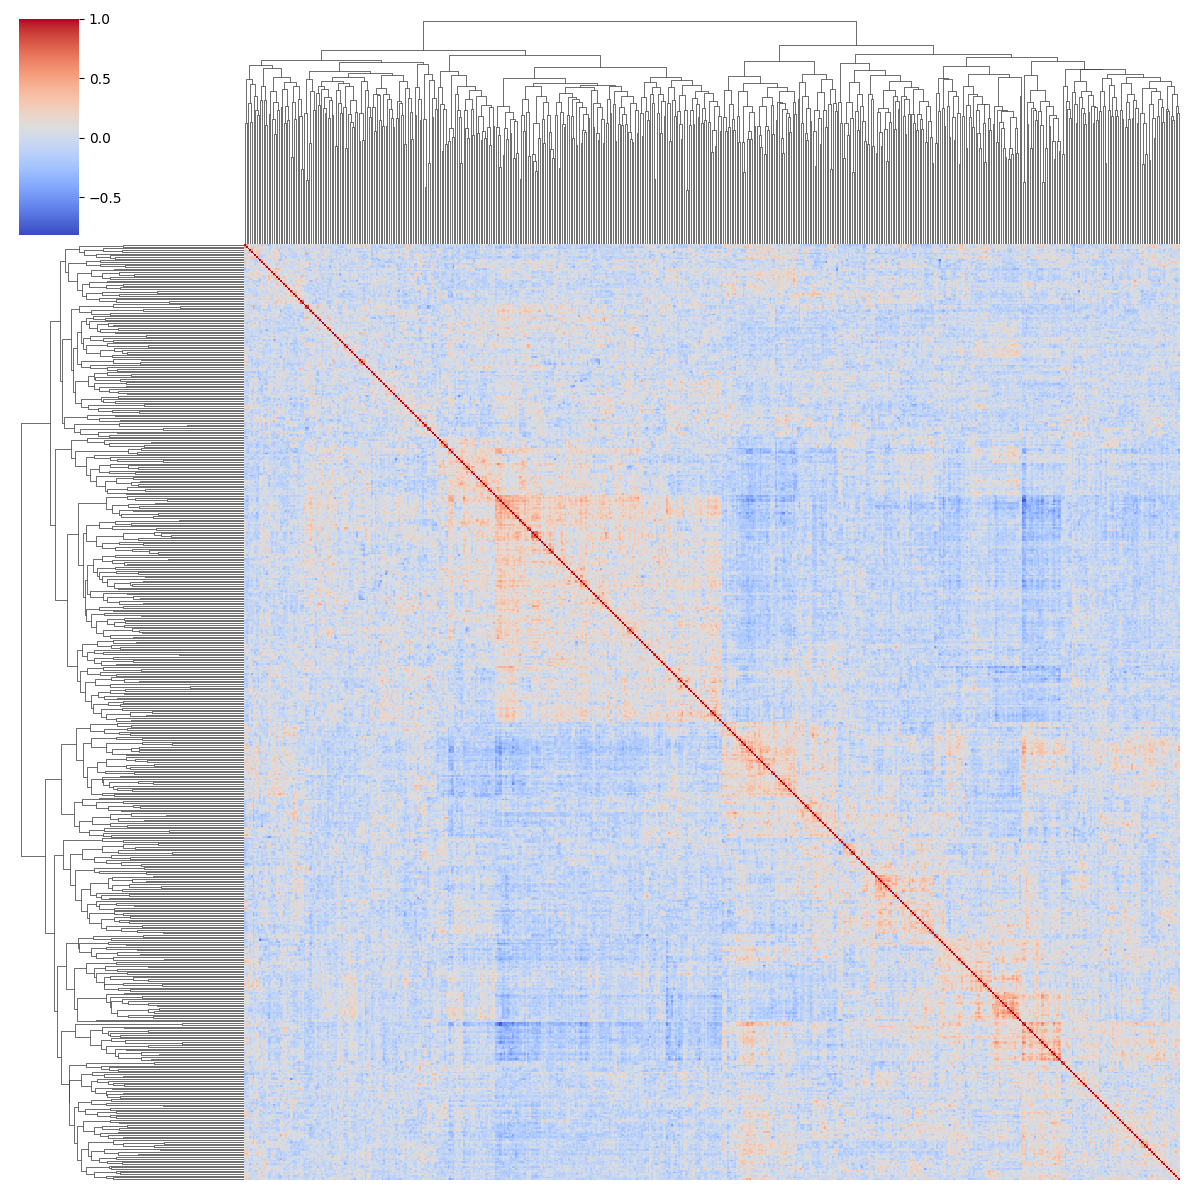

In [20]:
corr = X2.T.corr(method="pearson")

sns.clustermap(
    corr,
    cmap="coolwarm",
    figsize=(12,12),
    xticklabels=False,
    yticklabels=False
)

C:\users\Usuario\venv\lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\users\Usuario\venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\users\Usuario\venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
  File "C:\users\Usuario\venv\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\users\Usuario\venv\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  Fi

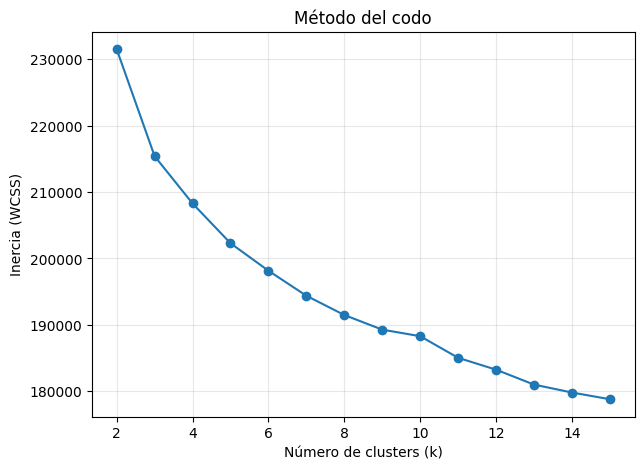

In [21]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K = range(2, 16)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    kmeans.fit(X2)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7,5))

plt.plot(K, inertia, marker='o')

plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia (WCSS)")
plt.title("Método del codo")

plt.grid(alpha=0.3)

plt.show()

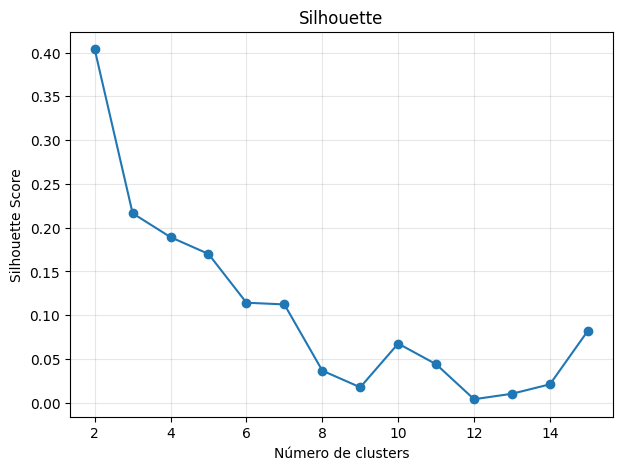

Mejor k = 2


In [22]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

scores = []

K = range(2, 16)

for k in K:

    labels = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    ).fit_predict(X2)

    score = silhouette_score(X2, labels)

    scores.append(score)

plt.figure(figsize=(7,5))

plt.plot(K, scores, marker="o")

plt.xlabel("Número de clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette")

plt.grid(alpha=0.3)

plt.show()

print(f"Mejor k = {K[scores.index(max(scores))]}")

In [23]:
from sklearn.cluster import KMeans

k = 2

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=20
)

labels = kmeans.fit_predict(X2)

clusters_asv = X2.copy()

clusters_asv["cluster"] = labels

clusters_asv

Run,SRR32936402,SRR32936389,SRR32938709,SRR32936396,SRR32936412,SRR32938731,SRR32938711,SRR32938723,SRR32938694,SRR32938705,...,SRR32938727,SRR32936398,SRR32936425,SRR32936411,SRR32936397,SRR32938719,SRR32936399,SRR32938700,SRR32936400,cluster
afc7d633b31eacbcd06f9bd00fc92aba,7.826119,-1.544053,-1.323049,8.202806,8.166590,-1.368005,-1.013931,-1.161852,-1.465493,-1.616949,...,5.573805,8.671835,5.912910,-1.506609,7.272687,-1.496125,5.863502,-1.413184,6.930358,1
d08c784d1836f43726d1162eadd9c4a4,7.800255,6.080566,4.136536,4.621091,5.834452,-1.368005,4.067473,-1.161852,-1.465493,3.739637,...,6.170724,3.537822,6.051437,5.899494,5.253448,5.683182,6.220812,0.784041,3.380689,1
b9678f89d81e366818a5f4e9a4dbcbf6,7.760835,-1.544053,5.376451,7.753502,7.109150,3.749989,-1.013931,-1.161852,5.157243,-1.616949,...,5.036119,7.336070,7.914567,3.175522,5.435925,3.831751,-1.497873,-1.413184,6.035706,1
2f2af02b1b3b9b47876e1c1f5c41d976,7.610936,5.308190,7.567912,8.676026,8.589347,7.303110,8.888155,6.965553,7.284873,5.999826,...,6.565470,8.278039,9.445464,5.364482,7.422768,7.928762,7.932084,5.850846,9.194470,1
3307f2605d463abcc42024cdfef4c1fe,7.579572,7.600682,8.052382,7.463803,7.236151,8.089117,9.876790,4.942941,8.948180,7.833982,...,9.994817,3.851795,6.935901,7.033323,7.782894,8.945170,7.217351,9.801228,6.849517,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
af321296818b6f22280afe5ca810ec2e,-1.330609,-1.544053,-1.323049,-1.204909,-1.608041,-1.368005,-1.013931,-1.161852,-1.465493,-1.616949,...,0.700136,-1.266199,4.237233,4.110162,-1.725697,-1.496125,-1.497873,-1.413184,-1.328841,0
37982d7213cf68b2468258261a050977,-1.330609,-1.544053,-1.323049,-1.204909,-1.608041,-1.368005,-1.013931,-1.161852,-1.465493,-1.616949,...,-0.909302,-1.266199,2.847040,-1.506609,2.550969,-1.496125,1.497859,1.631339,-1.328841,0
fe0d60c62bc7c9ce14dcb5cded7cddbd,-1.330609,-1.544053,-1.323049,-1.204909,-1.608041,-1.368005,-1.013931,-1.161852,-1.465493,-1.616949,...,0.189310,1.131696,-1.311843,-1.506609,2.631012,-1.496125,-1.497873,-1.413184,-1.328841,0
9677c16ff1cbe3c88a8e53631965290d,-1.330609,-1.544053,-1.323049,-1.204909,-1.608041,-1.368005,-1.013931,-1.161852,-1.465493,-1.616949,...,0.189310,-1.266199,-1.311843,-1.506609,-0.339403,-1.496125,-1.497873,2.324486,1.504372,0


In [24]:
clusters_asv["cluster"].value_counts().sort_index()

cluster
0    497
1     55
Name: count, dtype: int64

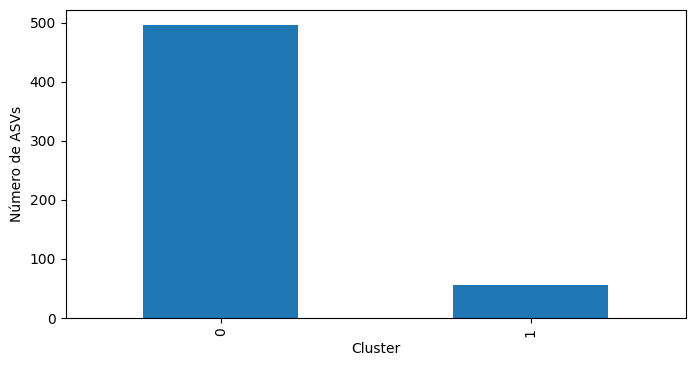

In [25]:
clusters_asv["cluster"].value_counts().sort_index().plot.bar(figsize=(8,4))

plt.xlabel("Cluster")
plt.ylabel("Número de ASVs")

plt.show()

In [26]:
tax_dict_azh = pd.read_csv(
    "taxonomy.tsv",
    sep="\t"
)
tax_dict = dict(zip(
    tax_dict_azh["Feature ID"],
    tax_dict_azh["Taxon"]
))

In [27]:
cluster_tax = clusters_asv.reset_index()

cluster_tax = cluster_tax.rename(
    columns={"index": "ASV"}
)

cluster_tax["Taxon"] = cluster_tax["ASV"].map(tax_dict)

cluster_tax.head()

Run,ASV,SRR32936402,SRR32936389,SRR32938709,SRR32936396,SRR32936412,SRR32938731,SRR32938711,SRR32938723,SRR32938694,...,SRR32936398,SRR32936425,SRR32936411,SRR32936397,SRR32938719,SRR32936399,SRR32938700,SRR32936400,cluster,Taxon
0,afc7d633b31eacbcd06f9bd00fc92aba,7.826119,-1.544053,-1.323049,8.202806,8.166590,-1.368005,-1.013931,-1.161852,-1.465493,...,8.671835,5.912910,-1.506609,7.272687,-1.496125,5.863502,-1.413184,6.930358,1,d__Bacteria; p__Firmicutes; c__Negativicutes; ...
1,d08c784d1836f43726d1162eadd9c4a4,7.800255,6.080566,4.136536,4.621091,5.834452,-1.368005,4.067473,-1.161852,-1.465493,...,3.537822,6.051437,5.899494,5.253448,5.683182,6.220812,0.784041,3.380689,1,d__Bacteria; p__Proteobacteria; c__Gammaproteo...
2,b9678f89d81e366818a5f4e9a4dbcbf6,7.760835,-1.544053,5.376451,7.753502,7.109150,3.749989,-1.013931,-1.161852,5.157243,...,7.336070,7.914567,3.175522,5.435925,3.831751,-1.497873,-1.413184,6.035706,1,d__Bacteria; p__Firmicutes; c__Bacilli; o__Lac...
3,2f2af02b1b3b9b47876e1c1f5c41d976,7.610936,5.308190,7.567912,8.676026,8.589347,7.303110,8.888155,6.965553,7.284873,...,8.278039,9.445464,5.364482,7.422768,7.928762,7.932084,5.850846,9.194470,1,d__Bacteria; p__Firmicutes; c__Bacilli; o__Lac...
4,3307f2605d463abcc42024cdfef4c1fe,7.579572,7.600682,8.052382,7.463803,7.236151,8.089117,9.876790,4.942941,8.948180,...,3.851795,6.935901,7.033323,7.782894,8.945170,7.217351,9.801228,6.849517,1,d__Bacteria; p__Firmicutes; c__Bacilli; o__Lac...


In [28]:
tax_levels = cluster_tax["Taxon"].str.split("; ", expand=True)

tax_levels.columns = [
    "Domain",
    "Phylum",
    "Class",
    "Order",
    "Family",
    "Genus",
    "Species"
]

cluster_tax = pd.concat(
    [
        cluster_tax.drop(columns=["Taxon"]),
        tax_levels
    ],
    axis=1
)

cluster_tax.head()

,ASV,SRR32936402,SRR32936389,SRR32938709,SRR32936396,SRR32936412,SRR32938731,SRR32938711,SRR32938723,SRR32938694,...,SRR32938700,SRR32936400,cluster,Domain,Phylum,Class,Order,Family,Genus,Species
0,afc7d633b31eacbcd06f9bd00fc92aba,7.826119,-1.544053,-1.323049,8.202806,8.166590,-1.368005,-1.013931,-1.161852,-1.465493,...,-1.413184,6.930358,1,d__Bacteria,p__Firmicutes,c__Negativicutes,o__Veillonellales-Selenomonadales,f__Veillonellaceae,g__Veillonella,None
1,d08c784d1836f43726d1162eadd9c4a4,7.800255,6.080566,4.136536,4.621091,5.834452,-1.368005,4.067473,-1.161852,-1.465493,...,0.784041,3.380689,1,d__Bacteria,p__Proteobacteria,c__Gammaproteobacteria,o__Burkholderiales,f__Neisseriaceae,g__Neisseria,None
2,b9678f89d81e366818a5f4e9a4dbcbf6,7.760835,-1.544053,5.376451,7.753502,7.109150,3.749989,-1.013931,-1.161852,5.157243,...,-1.413184,6.035706,1,d__Bacteria,p__Firmicutes,c__Bacilli,o__Lactobacillales,f__Streptococcaceae,g__Streptococcus,None
3,2f2af02b1b3b9b47876e1c1f5c41d976,7.610936,5.308190,7.567912,8.676026,8.589347,7.303110,8.888155,6.965553,7.284873,...,5.850846,9.194470,1,d__Bacteria,p__Firmicutes,c__Bacilli,o__Lactobacillales,f__Streptococcaceae,g__Streptococcus,None
4,3307f2605d463abcc42024cdfef4c1fe,7.579572,7.600682,8.052382,7.463803,7.236151,8.089117,9.876790,4.942941,8.948180,...,9.801228,6.849517,1,d__Bacteria,p__Firmicutes,c__Bacilli,o__Lactobacillales,f__Streptococcaceae,g__Streptococcus,None


In [29]:
cluster_0 = (
    cluster_tax[
        cluster_tax["cluster"] == 0
    ]
    .copy()
)

cluster_1 = (
    cluster_tax[
        cluster_tax["cluster"] == 1
    ]
    .copy()
)

In [32]:
cluster_0_genus = (
    cluster_0["Genus"]
    .value_counts()
    .reset_index()
)

cluster_0_genus.columns = [
    "Genus",
    "n_ASVs"
]

cluster_0_genus.head(20)

,Genus,n_ASVs
0,g__Actinomyces,59
1,g__Prevotella,31
2,g__Selenomonas,23
3,g__Leptotrichia,21
4,g__Stomatobaculum,20
5,g__Capnocytophaga,19
6,g__Lachnoanaerobaculum,19
7,g__Campylobacter,17
8,g__Treponema,16
9,g__Veillonella,14


In [31]:
cluster_1_genus = (
    cluster_1["Genus"]
    .value_counts()
    .reset_index()
)

cluster_1_genus.columns = [
    "Genus",
    "n_ASVs"
]

cluster_1_genus.head(20)

,Genus,n_ASVs
0,g__Streptococcus,8
1,g__Prevotella,7
2,g__Veillonella,6
3,g__Actinomyces,5
4,g__Haemophilus,4
5,g__Granulicatella,3
6,g__Gemella,3
7,g__Solobacterium,2
8,g__Neisseria,2
9,g__Porphyromonas,2


C:\users\Usuario\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


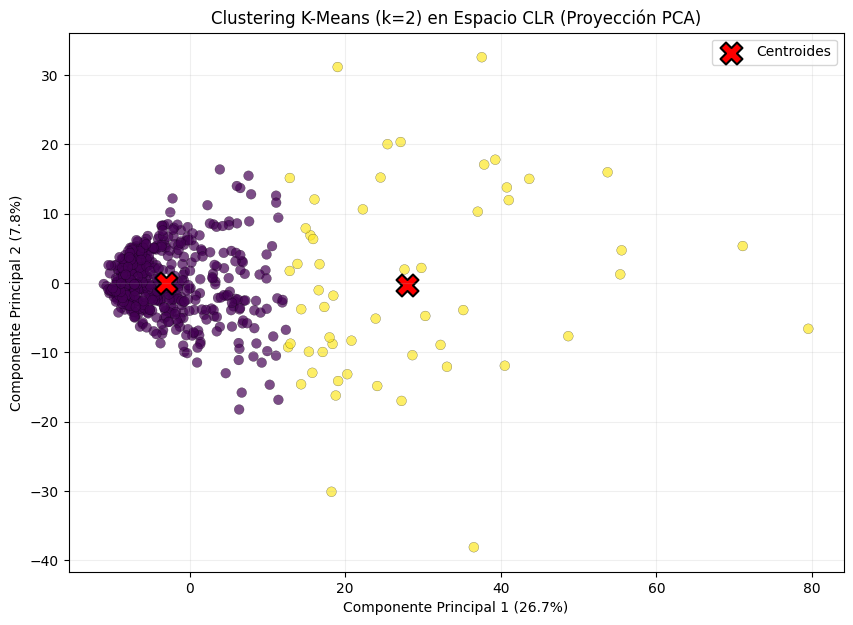

In [40]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

k = 2
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
labels = kmeans.fit_predict(X2)

pca = PCA(n_components=2)
X2_pca = pca.fit_transform(X2)
centroides_pca = pca.transform(kmeans.cluster_centers_)

var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100

plt.figure(figsize=(10, 7))

plt.scatter(
    X2_pca[:, 0],
    X2_pca[:, 1],
    c=labels,
    cmap="viridis",
    s=50,
    alpha=0.7,
    edgecolor="k",
    linewidth=0.2
)

plt.scatter(
    centroides_pca[:, 0],
    centroides_pca[:, 1],
    c="red",
    marker="X",
    s=250,
    edgecolor="black",
    linewidth=1.5,
    label="Centroides"
)

plt.xlabel(f"Componente Principal 1 ({var_pc1:.1f}%)")
plt.ylabel(f"Componente Principal 2 ({var_pc2:.1f}%)")
plt.title("Clustering K-Means (k=2) en Espacio CLR (Proyección PCA)")
plt.legend()
plt.grid(alpha=0.2)

plt.show()